## CNNs (Binary and MultiClass Classification)

The current data only have 2 classes (the original have 101 classes from the dataset Food101)

In [1]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
!unzip -q pizza_steak.zip -d pizza_steak_data

data_path = "./pizza_steak_data"
print("Data extracted to:", data_path)

--2026-07-03 12:05:28--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.2.207, 74.125.137.207, 142.250.101.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.2.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip’

pizza_steak.zip     100%[===================>] 104.47M   189MB/s    in 0.6s    

2026-07-03 12:05:29 (189 MB/s) - ‘pizza_steak.zip’ saved [109540975/109540975]

Data extracted to: ./pizza_steak_data


In [2]:
train_path = data_path + "/pizza_steak/train"
test_path = data_path + "/pizza_steak/test"

In [3]:
import warnings

warnings.filterwarnings('ignore')

Getting the classnames programatically

In [4]:
import pathlib
import numpy as np

data_dir = pathlib.Path(train_path)
classnames = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(classnames)


['pizza' 'steak']


Lets visualize our images

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os

def view_random_image(target_dir, target_class):
  target_folder = target_dir + "/" + target_class

  random_image = random.sample(os.listdir(target_folder), 1)

  img = mpimg.imread(target_folder + "/" + random_image[0])

  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off")
  print(f"Image shape: {img.shape}")
  plt.show()


Image shape: (512, 512, 3)


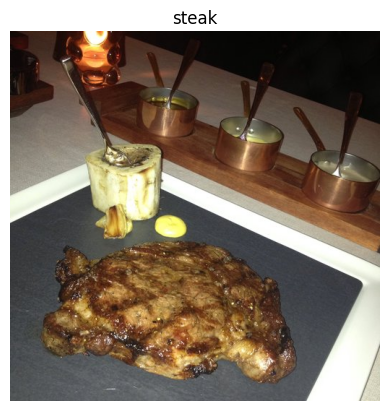

In [6]:
# classnames[0] = pizza , classnames[1] = steak
view_random_image(train_path, classnames[1])

## Load and Preprocessing (pixel values between 0 and 1)

In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tf.random.set_seed(42)

# Preprocess (0 - 1)
train_datagen = ImageDataGenerator(rescale=1.0 / 255)
valid_datagen = ImageDataGenerator(rescale=1.0 / 255)

# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(
    directory=train_path,
    batch_size=32,
    target_size=(224, 224),
    class_mode="binary", # only 2 classes till now
    seed=42,
)
valid_data = valid_datagen.flow_from_directory(
    directory=test_path,
    batch_size=32,
    target_size=(224, 224),
    class_mode="binary", # only 2 classes till now
    seed=42,
)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


## Build a CNN model (same as the tiny VGG on the CNN explainer website)

In [8]:
model1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(
        filters=10,
        kernel_size=3,
        activation='relu',
        input_shape=(224, 224, 3)
    ),
    tf.keras.layers.Conv2D(
        filters=10,
        kernel_size=3,
        activation='relu',
    ),
    tf.keras.layers.MaxPool2D(pool_size=2, padding="valid"),
    # if we didn't mention the stride, it automatically equals to the pool size i.e. 2
    tf.keras.layers.Conv2D(
        filters=10,
        kernel_size=3,
        activation='relu',
    ),
    tf.keras.layers.Conv2D(
        filters=10,
        kernel_size=3,
        activation='relu',
    ),
    tf.keras.layers.MaxPool2D(pool_size=2, padding="valid"), # if we didn't mention the stride, it automatically equals to the pool size i.e. 2
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=1, activation="sigmoid"),
])

# compiling the model
model1.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)

# fitting on data
history1 = model1.fit(
    train_data,
    epochs=5,
    # steps_per_epoch=len(train_data),
    validation_data=valid_data,
    # validation_steps=len(valid_data),
)

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 231ms/step - accuracy: 0.5880 - loss: 0.6499 - val_accuracy: 0.7760 - val_loss: 0.5137
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 139ms/step - accuracy: 0.7927 - loss: 0.4639 - val_accuracy: 0.8200 - val_loss: 0.3628
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.8280 - loss: 0.4111 - val_accuracy: 0.8440 - val_loss: 0.3506
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.8287 - loss: 0.3841 - val_accuracy: 0.8600 - val_loss: 0.3328
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - accuracy: 0.8547 - loss: 0.3502 - val_accuracy: 0.8680 - val_loss: 0.3099


In [9]:
model1.save('model1.keras')

In [10]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

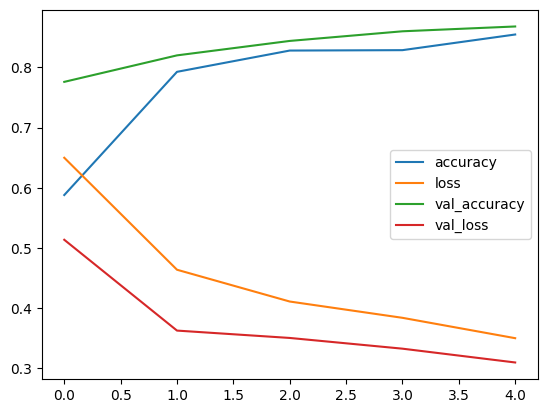

In [11]:
import pandas as pd

pd.DataFrame(history1.history).plot()
plt.show()

## Without CNN

In [12]:
model2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=10, activation="relu"),
    tf.keras.layers.Dense(units=10, activation="relu"),
    tf.keras.layers.Dense(units=1, activation="sigmoid"),
])

model2.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy'],
)

history2 = model2.fit(
    train_data,
    epochs=5,
    validation_data=valid_data,
)

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - accuracy: 0.5173 - loss: 2.5335 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932


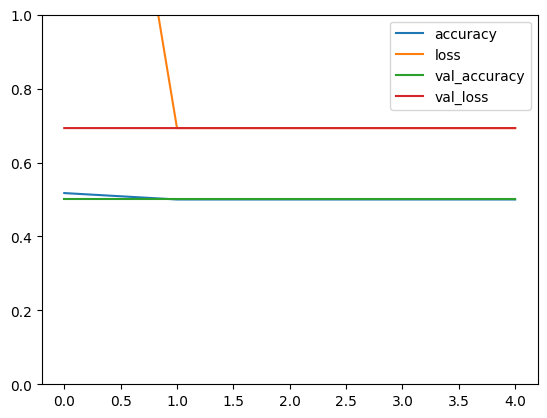

In [13]:
import pandas as pd

pd.DataFrame(history2.history).plot()
plt.ylim(0, 1)
plt.show()

## Data Augmentation with ImageDataGenerator

In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tf.random.set_seed(42)

# Preprocess (0 - 1)
train_datagen_augmented = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.3,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)
valid_datagen = ImageDataGenerator(rescale=1.0 / 255)

# Import data from directories and turn it into batches
train_data_augmented = train_datagen_augmented.flow_from_directory(
    directory=train_path,
    batch_size=32,
    target_size=(224, 224),
    class_mode="binary", # only 2 classes till now
    seed=42,
    shuffle=True,
)
valid_data = valid_datagen.flow_from_directory(
    directory=test_path,
    batch_size=32,
    target_size=(224, 224),
    class_mode="binary", # only 2 classes till now
    seed=42,
)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [15]:
model3 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(
        filters=10,
        kernel_size=3,
        activation='relu',
        input_shape=(224, 224, 3)
    ),
    tf.keras.layers.Conv2D(
        filters=10,
        kernel_size=3,
        activation='relu',
    ),
    tf.keras.layers.MaxPool2D(pool_size=2, padding="valid"),
    # if we didn't mention the stride, it automatically equals to the pool size i.e. 2
    tf.keras.layers.Conv2D(
        filters=10,
        kernel_size=3,
        activation='relu',
    ),
    tf.keras.layers.Conv2D(
        filters=10,
        kernel_size=3,
        activation='relu',
    ),
    tf.keras.layers.MaxPool2D(pool_size=2, padding="valid"), # if we didn't mention the stride, it automatically equals to the pool size i.e. 2
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=1, activation="sigmoid"),
])

# compiling the model
model3.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)

# fitting on data
history3 = model3.fit(
    train_data_augmented,
    epochs=5,
    # steps_per_epoch=len(train_data),
    validation_data=valid_data,
    # validation_steps=len(valid_data),
)

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 30s 555ms/step - accuracy: 0.6360 - loss: 0.6293 - val_accuracy: 0.7980 - val_loss: 0.4429
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 440ms/step - accuracy: 0.7573 - loss: 0.5172 - val_accuracy: 0.8120 - val_loss: 0.4063
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 464ms/step - accuracy: 0.7473 - loss: 0.5171 - val_accuracy: 0.7560 - val_loss: 0.4769
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 481ms/step - accuracy: 0.7733 - loss: 0.4923 - val_accuracy: 0.8400 - val_loss: 0.3606
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 448ms/step - accuracy: 0.7573 - loss: 0.5009 - val_accuracy: 0.7920 - val_loss: 0.4489


## Making predictions on Custom Data

Resizes `custom_image` to 224×224 (matching the model's training input size), scales pixel values from 0–255 to 0–1, then adds a batch dimension so the tensor shape becomes `(1, 224, 224, 3)` — ready for `model.predict()`.

--2026-07-03 12:14:25--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/images/03-steak.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1978213 (1.9M) [image/jpeg]
Saving to: ‘03-steak.jpeg.1’

03-steak.jpeg.1     100%[===================>]   1.89M  --.-KB/s    in 0.04s   

2026-07-03 12:14:26 (43.3 MB/s) - ‘03-steak.jpeg.1’ saved [1978213/1978213]



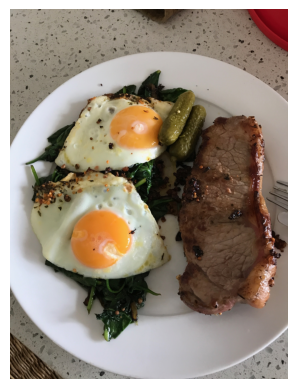

In [22]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/images/03-steak.jpeg

filename = './03-steak.jpeg'
steak = mpimg.imread(filename)
plt.imshow(steak)
plt.axis("off")
plt.show()

In [23]:
def load_and_prep_image(filename, img_size=224):
  img = tf.io.read_file(filename)
  img = tf.image.decode_image(img)
  img = tf.image.resize(img, size=[img_size, img_size])
  img = img/255.
  img = tf.expand_dims(img, axis=0)
  return img

In [17]:
model1 = tf.keras.models.load_model('./model1.keras')

In [26]:
loaded_img = load_and_prep_image(filename)
classnames[int(np.round(model1.predict(loaded_img))[0][0])]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


np.str_('steak')

## Multiclass Image Classification on Same Data with Multi Classes

In [27]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip

!unzip -q 10_food_classes_all_data.zip -d 10_food_classes_all_data

data_path = './10_food_classes_all_data/10_food_classes_all_data'

--2026-07-03 12:39:02--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.2.207, 74.125.137.207, 142.250.101.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.2.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip’

10_food_classes_all 100%[===================>] 495.13M  51.4MB/s    in 11s     

2026-07-03 12:39:14 (44.0 MB/s) - ‘10_food_classes_all_data.zip’ saved [519183241/519183241]



In [32]:
train_path = data_path + "/train"
test_path = data_path + "/test"

In [33]:
import pathlib
import numpy as np

data_dir = pathlib.Path(train_path)
classnames = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(classnames)


['chicken_curry' 'chicken_wings' 'fried_rice' 'grilled_salmon' 'hamburger'
 'ice_cream' 'pizza' 'ramen' 'steak' 'sushi']


Image shape: (512, 512, 3)


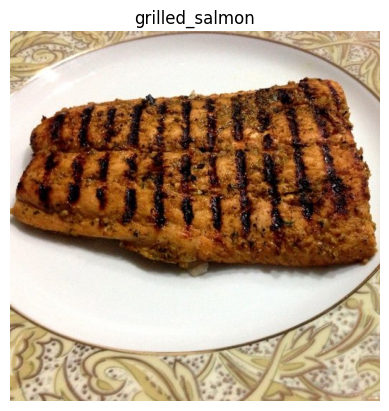

In [39]:
view_random_image(train_path, random.choice(classnames))

## Preprocessing Multiclass images

In [40]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tf.random.set_seed(42)

# Preprocess (0 - 1)
train_datagen = ImageDataGenerator(rescale=1.0 / 255)
valid_datagen = ImageDataGenerator(rescale=1.0 / 255)

# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(
    directory=train_path,
    batch_size=32,
    target_size=(224, 224),
    class_mode="categorical", # only 2 classes till now
    seed=42,
)
valid_data = valid_datagen.flow_from_directory(
    directory=test_path,
    batch_size=32,
    target_size=(224, 224),
    class_mode="categorical", # only 2 classes till now
    seed=42,
)

Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


## Modeling

In [43]:
model4 = tf.keras.Sequential(
    [
        tf.keras.layers.Conv2D(
            filters=10, kernel_size=3, activation="relu", input_shape=(224, 224, 3)
        ),
        tf.keras.layers.Conv2D(filters=10, kernel_size=3, activation="relu"),
        tf.keras.layers.MaxPool2D(pool_size=2, padding="valid"),
        # if we didn't mention the stride, it automatically equals to the pool size i.e. 2
        tf.keras.layers.Conv2D(filters=10, kernel_size=3, activation="relu"),
        tf.keras.layers.Conv2D(filters=10, kernel_size=3, activation="relu"),
        tf.keras.layers.MaxPool2D(
            pool_size=2, padding="valid"
        ),  # if we didn't mention the stride, it automatically equals to the pool size i.e. 2
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(units=len(classnames), activation="softmax"),
    ]
)

# compiling the model
model4.compile(
    loss="categorical_crossentropy",  # or 'sparse_categorical_crossentropy'
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"],
)

# fitting on data
history1 = model4.fit(
    train_data,
    epochs=5,
    validation_data=valid_data,
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 32s 124ms/step - accuracy: 0.2431 - loss: 2.1000 - val_accuracy: 0.2996 - val_loss: 1.9624
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 31s 131ms/step - accuracy: 0.3769 - loss: 1.8178 - val_accuracy: 0.3772 - val_loss: 1.7813
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 112ms/step - accuracy: 0.5176 - loss: 1.4440 - val_accuracy: 0.3368 - val_loss: 1.9950
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 127ms/step - accuracy: 0.7251 - loss: 0.8531 - val_accuracy: 0.3080 - val_loss: 2.4270
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 116ms/step - accuracy: 0.8901 - loss: 0.3610 - val_accuracy: 0.2696 - val_loss: 3.4217


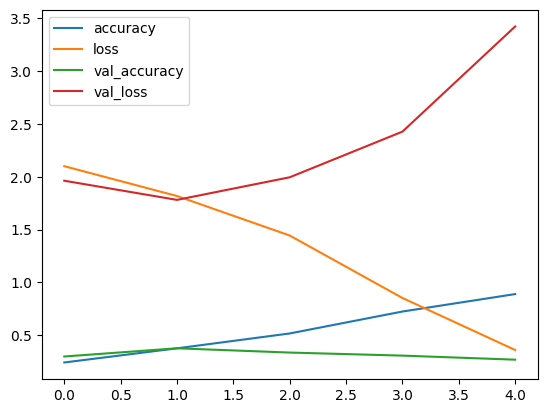

In [44]:
import pandas as pd

pd.DataFrame(history1.history).plot()
plt.show()

## Reducing Overfitting

### Experiment #1 (Reduce Model Complexity)

*Didn't Work* (Use transfer learning)

In [46]:
model5 = tf.keras.Sequential(
    [
        tf.keras.layers.Conv2D(
            filters=10, kernel_size=3, activation="relu", input_shape=(224, 224, 3)
        ),
        tf.keras.layers.MaxPool2D(pool_size=2, padding="valid"),
        # if we didn't mention the stride, it automatically equals to the pool size i.e. 2
        tf.keras.layers.Conv2D(filters=10, kernel_size=3, activation="relu"),
        tf.keras.layers.MaxPool2D(
            pool_size=2, padding="valid"
        ),  # if we didn't mention the stride, it automatically equals to the pool size i.e. 2
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(units=len(classnames), activation="softmax"),
    ]
)

# compiling the model
model5.compile(
    loss="categorical_crossentropy",  # or 'sparse_categorical_crossentropy'
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"],
)

# fitting on data
history1 = model5.fit(
    train_data,
    epochs=5,
    validation_data=valid_data,
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 117ms/step - accuracy: 0.2701 - loss: 2.0379 - val_accuracy: 0.3304 - val_loss: 1.8774
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 109ms/step - accuracy: 0.4309 - loss: 1.6882 - val_accuracy: 0.3700 - val_loss: 1.7871
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 25s 108ms/step - accuracy: 0.5995 - loss: 1.2540 - val_accuracy: 0.3780 - val_loss: 1.8828
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 29s 125ms/step - accuracy: 0.7665 - loss: 0.7735 - val_accuracy: 0.3384 - val_loss: 2.1111
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 25s 107ms/step - accuracy: 0.9004 - loss: 0.3910 - val_accuracy: 0.3456 - val_loss: 2.4979


### Experiment #2 (Data Augmentation)

*Didn't Work* (Use transfer learning)

In [47]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tf.random.set_seed(42)

# Preprocess (0 - 1)
train_datagen_augmented = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.3,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)
valid_datagen = ImageDataGenerator(rescale=1.0 / 255)

# Import data from directories and turn it into batches
train_data_augmented = train_datagen_augmented.flow_from_directory(
    directory=train_path,
    batch_size=32,
    target_size=(224, 224),
    class_mode="categorical",
    seed=42,
    shuffle=True,
)
valid_data = valid_datagen.flow_from_directory(
    directory=test_path,
    batch_size=32,
    target_size=(224, 224),
    class_mode="categorical",
    seed=42,
)

Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


In [48]:
model6 = tf.keras.Sequential(
    [
        tf.keras.layers.Conv2D(
            filters=10, kernel_size=3, activation="relu", input_shape=(224, 224, 3)
        ),
        tf.keras.layers.Conv2D(filters=10, kernel_size=3, activation="relu"),
        tf.keras.layers.MaxPool2D(pool_size=2, padding="valid"),
        # if we didn't mention the stride, it automatically equals to the pool size i.e. 2
        tf.keras.layers.Conv2D(filters=10, kernel_size=3, activation="relu"),
        tf.keras.layers.Conv2D(filters=10, kernel_size=3, activation="relu"),
        tf.keras.layers.MaxPool2D(
            pool_size=2, padding="valid"
        ),  # if we didn't mention the stride, it automatically equals to the pool size i.e. 2
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(units=len(classnames), activation="softmax"),
    ]
)

# compiling the model
model6.compile(
    loss="categorical_crossentropy",  # or 'sparse_categorical_crossentropy'
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"],
)

# fitting on data
history1 = model6.fit(
    train_data_augmented,
    epochs=5,
    validation_data=valid_data,
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 113s 465ms/step - accuracy: 0.1445 - loss: 2.2687 - val_accuracy: 0.1944 - val_loss: 2.1599
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 109s 465ms/step - accuracy: 0.2445 - loss: 2.1003 - val_accuracy: 0.3136 - val_loss: 1.9332
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 114s 485ms/step - accuracy: 0.2819 - loss: 2.0229 - val_accuracy: 0.3228 - val_loss: 1.9021
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 109s 465ms/step - accuracy: 0.3073 - loss: 1.9723 - val_accuracy: 0.3420 - val_loss: 1.8884
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 110s 467ms/step - accuracy: 0.3155 - loss: 1.9534 - val_accuracy: 0.4080 - val_loss: 1.7457


In [49]:
model6.save("model6.keras")

In [61]:
filename = './03-steak.jpeg' # this is not performing good it should be steak
loaded_img = load_and_prep_image(filename)
classnames[np.argmax(model6.predict(loaded_img))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


np.str_('steak')